# 🔧 02 — Feature Engineering
### Data Flow
```
data/01_raw.csv → encode → resample → split → scale → save splits
                                                      ↓
                                         data/02_train.csv
                                         data/02_val.csv
                                         data/02_test.csv
                                         outputs/scaler.pkl
```


In [1]:

import warnings; warnings.filterwarnings('ignore')
import os, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

os.makedirs('../data',    exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
os.makedirs('plots',      exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.1)
SEED = 42


## 1. Load from Previous Notebook

In [2]:

df = pd.read_csv('../data/01_raw.csv')
print(f"Loaded: {df.shape}  |  Columns: {df.columns.tolist()}")

X = df.drop(columns=['DEFAULT']).values.astype(np.float32)
y = df['DEFAULT'].values.astype(np.float32)
feature_names = df.drop(columns=['DEFAULT']).columns.tolist()

print(f"\nFeatures : {len(feature_names)}")
print(f"Samples  : {len(y):,}  |  Default rate: {y.mean():.1%}")


Loaded: (30000, 24)  |  Columns: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']

Features : 23
Samples  : 30,000  |  Default rate: 22.1%


## 2. Class Imbalance — Before vs After Resampling

Before resampling: Counter({np.int64(0): 23364, np.int64(1): 6636})
After resampling : Counter({np.int64(0): 23364, np.int64(1): 9345})


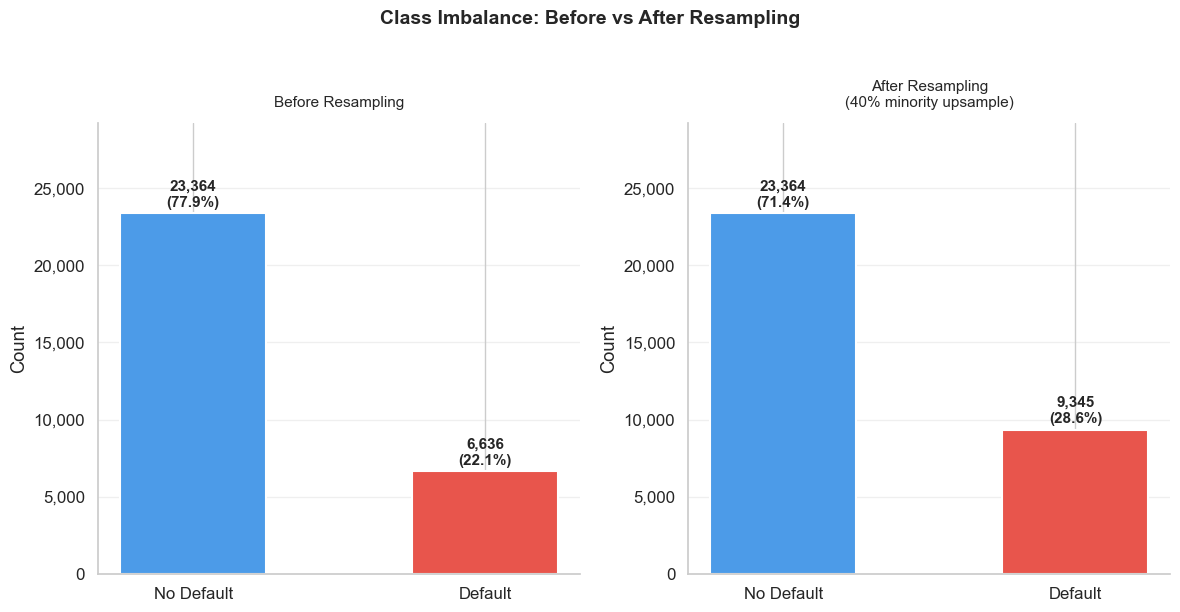

In [ ]:

print("Before resampling:", Counter(y.astype(int)))

# Separate classes
df_temp              = pd.DataFrame(X, columns=feature_names)
df_temp['__target__'] = y

df_maj    = df_temp[df_temp['__target__'] == 0]
df_min    = df_temp[df_temp['__target__'] == 1]

df_min_up = resample(df_min, replace=True,
                     n_samples=int(len(df_maj) * 0.4),
                     random_state=SEED)

df_bal = pd.concat([df_maj, df_min_up], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True) # type: ignore

X_bal = df_bal.drop(columns=['__target__']).values.astype(np.float32)
y_bal = df_bal['__target__'].values.astype(np.float32)
print("After resampling :", Counter(y_bal.astype(int)))

# Plot
before = Counter(y.astype(int))
after  = Counter(y_bal.astype(int))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Class Imbalance: Before vs After Resampling',
             fontsize=14, fontweight='bold', y=1.02)

for ax, counts, title in zip(axes,
    [before, after],
    ['Before Resampling', 'After Resampling\n(40% minority upsample)']):
    total = sum(counts.values())
    vals  = [counts[0], counts[1]]
    bars  = ax.bar(['No Default', 'Default'], vals,
                   color=['#4C9BE8', '#E8554C'],
                   edgecolor='white', linewidth=1.5, width=0.5)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 250,
                f'{v:,}\n({v/total:.1%})',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/02_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Train / Validation / Test Split

Train : (22241, 23)  |  Default rate: 28.6%
Val   : (3926, 23)    |  Default rate: 28.6%
Test  : (6542, 23)   |  Default rate: 28.6%


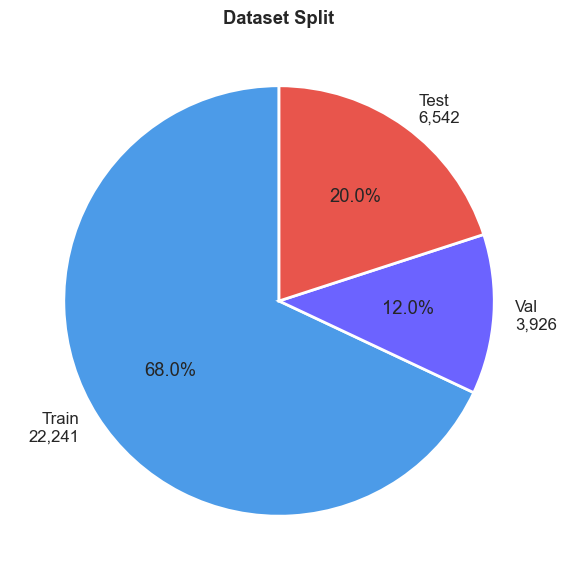

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.20, random_state=SEED, stratify=y_bal)
X_train, X_val, y_train, y_val   = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train)

print(f"Train : {X_train.shape}  |  Default rate: {y_train.mean():.1%}")
print(f"Val   : {X_val.shape}    |  Default rate: {y_val.mean():.1%}")
print(f"Test  : {X_test.shape}   |  Default rate: {y_test.mean():.1%}")

# Pie
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie([len(X_train), len(X_val), len(X_test)],
       labels=[f'Train\n{len(X_train):,}', f'Val\n{len(X_val):,}',
               f'Test\n{len(X_test):,}'],
       colors=['#4C9BE8', '#6C63FF', '#E8554C'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Dataset Split', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_dataset_split.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. StandardScaler — Fit on Train Only

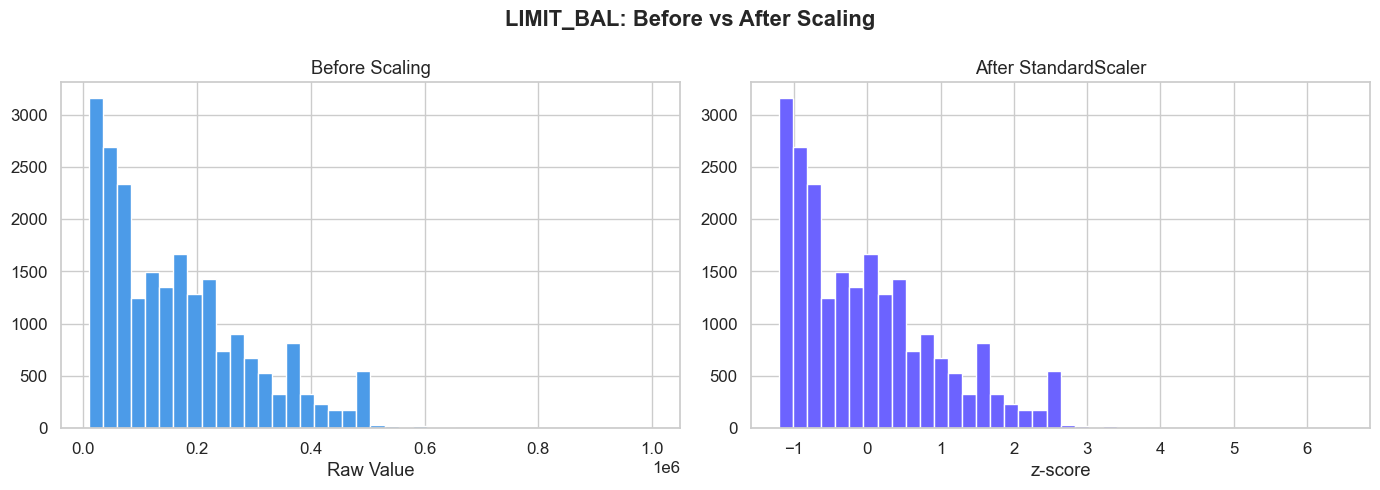

Scaler mean_[0]  = 165104.15
Scaler scale_[0] = 128820.54

✅ Scaler saved to outputs/scaler.pkl


In [ ]:

scaler      = StandardScaler()
X_train_s   = scaler.fit_transform(X_train)   # fit + transform
X_val_s     = scaler.transform(X_val)          # transform only
X_test_s    = scaler.transform(X_test)         # transform only

# Before / after comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LIMIT_BAL: Before vs After Scaling', fontweight='bold')
axes[0].hist(X_train[:, 0],  bins=40, color='#4C9BE8', edgecolor='white')
axes[0].set_title('Before Scaling'); axes[0].set_xlabel('Raw Value')
axes[1].hist(X_train_s[:, 0], bins=40, color='#6C63FF', edgecolor='white')
axes[1].set_title('After StandardScaler'); axes[1].set_xlabel('z-score')
plt.tight_layout()
plt.savefig('plots/02_scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Scaler mean_[0]  = {scaler.mean_[0]:.2f}") # type: ignore
print(f"Scaler scale_[0] = {scaler.scale_[0]:.2f}") # type: ignore

# Save scaler
with open('../outputs/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\n✅ Scaler saved to outputs/scaler.pkl")


## 5. Baseline Feature Importance (Random Forest)

Random Forest Val AUC: 0.8975  (DNN target: >0.79)


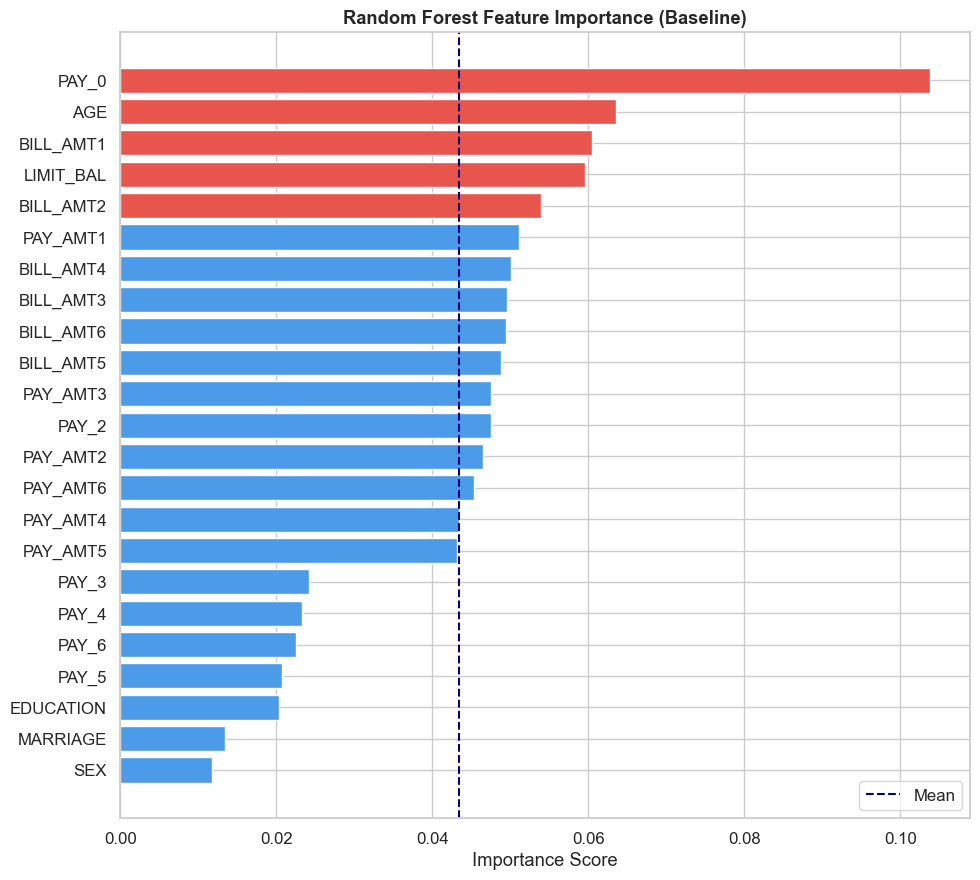

In [ ]:

rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train_s, y_train)
val_auc = roc_auc_score(y_val, rf.predict_proba(X_val_s)[:, 1])
print(f"Random Forest Val AUC: {val_auc:.4f}  (DNN target: >0.79)")

importances = pd.Series(rf.feature_importances_,
                        index=feature_names).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 9))
colors  = ['#E8554C' if i >= len(importances)-5 else '#4C9BE8'
           for i in range(len(importances))]
ax.barh(importances.index, importances.values, color=colors, edgecolor='white') # type: ignore
ax.axvline(importances.mean(), color='navy', linestyle='--', label='Mean')
ax.set_title('Random Forest Feature Importance (Baseline)', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.savefig('plots/02_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## ✅ Save Processed Splits

In [8]:

# Combine features + labels back into DataFrames
def to_df(X_scaled, y_arr):
    d = pd.DataFrame(X_scaled, columns=feature_names)
    d['DEFAULT'] = y_arr.astype(int)
    return d

df_train = to_df(X_train_s, y_train)
df_val   = to_df(X_val_s,   y_val)
df_test  = to_df(X_test_s,  y_test)

df_train.to_csv('../data/02_train.csv', index=False)
df_val.to_csv(  '../data/02_val.csv',   index=False)
df_test.to_csv( '../data/02_test.csv',  index=False)

print("✅ Saved:")
print(f"   data/02_train.csv  → {df_train.shape}")
print(f"   data/02_val.csv    → {df_val.shape}")
print(f"   data/02_test.csv   → {df_test.shape}")
print(f"   outputs/scaler.pkl → fitted StandardScaler")


✅ Saved:
   data/02_train.csv  → (22241, 24)
   data/02_val.csv    → (3926, 24)
   data/02_test.csv   → (6542, 24)
   outputs/scaler.pkl → fitted StandardScaler
